In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
import torchvision.transforms.functional as TF
import torch.nn.functional as F
import random

In [2]:
import shutil
from pathlib import Path
import pandas as pd

# ===============================
# CONFIG
# ===============================
IMG_PREFIX = "mz_binary_"
IMG_EXT = ".png"

# Dataset A
A_IMG_DIR = Path("../images/corrected")
A_CSV     = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected/training_index.csv")

# Dataset B
B_IMG_DIR = Path("../images/corrected_2")
B_CSV     = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_2/training_index.csv")

# Output (nuevo dataset)
OUT_IMG_DIR = Path("../dataset_combined/images")
OUT_CSV     = Path("../dataset_combined/training_index.csv")

OUT_IMG_DIR.mkdir(parents=True, exist_ok=True)

# ===============================
# LOAD CSVs (FIXED)
# ===============================
df_A = pd.read_csv(A_CSV, index_col=0)
df_B = pd.read_csv(B_CSV, index_col=0)

# Name the index properly
df_A.index.name = "run_id"
df_B.index.name = "run_id"

# ===============================
# SANITY CHECKS
# ===============================
assert "sigma" in df_A.columns, "Dataset A must have column 'sigma'"
assert "sigma_nominal" in df_B.columns, "Dataset B must have 'sigma_nominal'"

# ===============================
# COPY DATASET A
# ===============================
print("Copying dataset A images...")

for run_id in df_A.index:
    src = A_IMG_DIR / f"{IMG_PREFIX}{run_id}{IMG_EXT}"
    dst = OUT_IMG_DIR / f"{IMG_PREFIX}{run_id}{IMG_EXT}"

    if not src.exists():
        raise FileNotFoundError(src)

    shutil.copy2(src, dst)

print(f"  -> {len(df_A)} images copied")

# ===============================
# PREPARE DATASET B
# ===============================
print("Preparing dataset B...")

df_B = df_B.copy()

# Unify sigma definition
df_B["sigma"] = df_B["sigma_nominal"]

offset = int(df_A.index.max())

new_rows = []

for run_id, row in df_B.iterrows():
    new_id = int(run_id) + offset

    src = B_IMG_DIR / f"{IMG_PREFIX}{run_id}{IMG_EXT}"
    dst = OUT_IMG_DIR / f"{IMG_PREFIX}{new_id}{IMG_EXT}"

    if not src.exists():
        raise FileNotFoundError(src)

    shutil.copy2(src, dst)

    new_row = row.copy()
    new_row.name = new_id
    new_rows.append(new_row)

df_B_new = pd.DataFrame(new_rows)
df_B_new.index.name = "run_id"

print(f"  -> {len(df_B_new)} images copied and reindexed")

# ===============================
# MERGE CSVs
# ===============================
df_combined = pd.concat([df_A, df_B_new])
df_combined = df_combined.sort_index()

df_combined.to_csv(OUT_CSV)

print("\n✅ Combined dataset created successfully")
print(f"Images folder: {OUT_IMG_DIR}")
print(f"CSV file:      {OUT_CSV}")
print(f"Total samples: {len(df_combined)}")
print("Columns:", list(df_combined.columns))


Copying dataset A images...
  -> 506 images copied
Preparing dataset B...
  -> 591 images copied and reindexed

✅ Combined dataset created successfully
Images folder: ../dataset_combined/images
CSV file:      ../dataset_combined/training_index.csv
Total samples: 1097
Columns: ['sample_idx', 'realization', 'Dind', 'Ku1', 'Aex', 'alpha', 'Temp', 'sigma', 'mx3_path', 'out_dir', 'returncode', 'timestamp_start', 'timestamp_end', 'sigma_nominal', 'sigma_eff', 'clamp_fraction']


In [3]:
# -----------------------------
# 1) Config 
# -----------------------------
CSV_PATH = Path("../dataset_combined/training_index.csv")
IMG_DIR = Path("../dataset_combined/images")
#CSV_PATH = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_2/training_index.csv")
#IMG_DIR = Path("../images/corrected_2")
IMG_INDEX_COL = "run_id"  

COL_D = "Dind"
COL_SIGMA = "sigma"

IMG_EXT = ".png"   # image extension
IMG_PREFIX = "mz_binary_"   # image name pattern: mz_binary_<idx>.png

BATCH_SIZE = 10
LR = 5e-5
EPOCHS = 100
VAL_RATIO = 0.15
RANDOM_SEED = 5    #42
MODEL_TYPE = "physics_normal"   # Options: "resnet", "physics", "normal", "physics_normal" 
TRAIN_SURROGATE = True   # whether to train surrogate model or load pre-trained weights
USE_AUGMENTATION = False   # True / False para la prueba

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [4]:
def compute_image_observables(img_batch, n_radial_bins=64):
    """
    Compute physics-informed spatial correlation observables C(r).

    This defines the PHYSICAL representation Phi used
    for the PINN constraint. The CNN output remains (D, sigma).

    Parameters
    ----------
    img_batch : torch.Tensor
        Shape [B, 3, H, W], values in [0,1]
        (Only channel 0 is used)

    n_radial_bins : int
        Maximum correlation radius R (in pixels)

    Returns
    -------
    Phi : torch.Tensor
        Shape [B, n_radial_bins + 1]
        [
          C(1), C(2), ..., C(R),
          L_corr
        ]
    """

    # -------------------------------------------------
    # 1) mz channel in [-1, 1]
    # -------------------------------------------------
    x = img_batch[:, 0, :, :]          # [B, H, W]
    x = 2.0 * x - 1.0

    B, H, W = x.shape
    eps = 1e-8

    # -------------------------------------------------
    # 2) Remove spatial mean (critical)
    # -------------------------------------------------
    x = x - x.mean(dim=(1, 2), keepdim=True)

    # -------------------------------------------------
    # 3) Autocorrelation via FFT
    #    C = F^{-1}(|F(x)|^2)
    # -------------------------------------------------
    Fx = torch.fft.fft2(x)
    P = Fx.real**2 + Fx.imag**2
    C = torch.fft.ifft2(P).real

    # Normalize: C(0) = 1
    C0 = C[:, 0, 0].clamp_min(eps)
    C = C / C0[:, None, None]

    # -------------------------------------------------
    # 4) Radial distance grid (pixels)
    # -------------------------------------------------
    yy = torch.fft.fftfreq(H, device=x.device) * H
    xx = torch.fft.fftfreq(W, device=x.device) * W
    Y, X = torch.meshgrid(yy, xx, indexing="ij")
    r = torch.sqrt(X**2 + Y**2)

    r_int = torch.round(r).long()
    max_r = min(n_radial_bins, r_int.max().item())

    # -------------------------------------------------
    # 5) Isotropic radial averaging → C(r)
    # -------------------------------------------------
    C_flat = C.reshape(B, -1)
    r_flat = r_int.reshape(-1)

    Cr = []
    for rr in range(1, max_r + 1):
        mask = (r_flat == rr).float()
        denom = mask.sum().clamp_min(1.0)
        Cr_r = (C_flat * mask).sum(dim=1) / denom
        Cr.append(Cr_r)

    Cr = torch.stack(Cr, dim=1)   # [B, R]

    # Pad if needed (for safety)
    if Cr.shape[1] < n_radial_bins:
        pad = torch.zeros(B, n_radial_bins - Cr.shape[1], device=x.device)
        Cr = torch.cat([Cr, pad], dim=1)

    # -------------------------------------------------
    # 6) Correlation length L_corr
    #    First zero crossing
    # -------------------------------------------------
    sign = torch.sign(Cr)
    zero_cross = (sign[:, :-1] * sign[:, 1:] < 0)

    L_corr = torch.where(
        zero_cross.any(dim=1),
        zero_cross.float().argmax(dim=1) + 1,
        torch.full((B,), float(n_radial_bins), device=x.device)
    )

    # -------------------------------------------------
    # 7) Final Phi
    # -------------------------------------------------
    Phi = torch.cat(
        [
            Cr,                      # spatial correlations
            L_corr.unsqueeze(1)      # correlation length
        ],
        dim=1
    )

    return Phi


In [5]:
class MzDataset(Dataset):
    def __init__(self, csv_path, img_dir, index_col,
                 transform=None,
                 target_mean=None,
                 target_std=None):

        self.df = pd.read_csv(csv_path)
        self.df.set_index(index_col, inplace=True)

        self.img_dir = Path(img_dir)
        self.transform = transform

        self.records = []

        # Find all available images
        img_files = sorted(self.img_dir.glob(f"{IMG_PREFIX}*{IMG_EXT}"))

        if len(img_files) == 0:
            raise RuntimeError(f"No images found in {img_dir}")

        for img_path in img_files:
            # Extract run_id from filename
            try:
                run_id = int(img_path.stem.replace(IMG_PREFIX, ""))
            except ValueError:
                continue  # skip malformed filenames

            # Only keep images that have a matching CSV entry
            if run_id not in self.df.index:
                continue

            row = self.df.loc[run_id]

            self.records.append({
                "img_path": img_path,
                "D": float(row[COL_D]),
                "sigma": float(row[COL_SIGMA]),
                "run_id": run_id
            })

        if len(self.records) == 0:
            raise RuntimeError("No valid (image, label) pairs found.")

        self.target_mean = target_mean
        self.target_std  = target_std

        print(f"[MzDataset] Loaded {len(self.records)} samples from {img_dir}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        # Load image
        img = Image.open(r["img_path"]).convert("L")
        if self.transform is not None:
            img = self.transform(img)

        # Expand to 3 channels (CNN compatibility)
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        # Targets
        target = np.array([r["D"], r["sigma"]], dtype=np.float32)

        if self.target_mean is not None:
            target = (target - self.target_mean) / self.target_std

        target = torch.tensor(target, dtype=torch.float32)

        return img, target


In [7]:
# ---------------------------------------------------------
# 1. Define transforms
# ---------------------------------------------------------
class RandomRot90:
    def __call__(self, x):
        k = random.randint(0, 3)
        return TF.rotate(x, k * 90)

if USE_AUGMENTATION:
    train_tf = T.Compose([
        T.RandomHorizontalFlip(),
        T.RandomVerticalFlip(),
        RandomRot90(),
        T.ToTensor(),
    ])
else:
    train_tf = T.Compose([
        T.ToTensor(),
    ])

val_tf = T.Compose([
    T.ToTensor(),
])


# ---------------------------------------------------------
# 2. Base dataset (NO transforms yet)
# ---------------------------------------------------------
base_dataset = MzDataset(
    CSV_PATH,
    IMG_DIR,
    IMG_INDEX_COL,
    transform=None
)


# ---------------------------------------------------------
# 3. Train / Val split
# ---------------------------------------------------------
val_size = int(len(base_dataset) * VAL_RATIO)
train_size = len(base_dataset) - val_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(
    base_dataset,
    [train_size, val_size],
    generator=generator
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")


# ---------------------------------------------------------
# 4. Inject transforms (CRITICAL STEP)
# ---------------------------------------------------------
train_targets = np.array(
    [[base_dataset.records[i]["D"], base_dataset.records[i]["sigma"]]
     for i in train_dataset.indices],
    dtype=np.float32
)

t_mean = train_targets.mean(axis=0)
t_std  = train_targets.std(axis=0)
t_std[t_std == 0] = 1.0

train_dataset.dataset.transform = train_tf
train_dataset.dataset.target_mean = t_mean
train_dataset.dataset.target_std  = t_std

val_dataset.dataset.transform = val_tf
val_dataset.dataset.target_mean = t_mean
val_dataset.dataset.target_std  = t_std


# ---------------------------------------------------------
# 5. DataLoaders
# ---------------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)


[MzDataset] Loaded 1097 samples from ../dataset_combined/images
Train size: 933, Val size: 164


In [8]:
# -----------------------------
# Physics-Normal CNN
# imagen → (D, sigma)
# -----------------------------
class PhysicsNormalCNN(nn.Module):
    def __init__(self):
        super().__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        # Feature extractor
        self.features = nn.Sequential(
            conv_block(3, 32),    # -> [32, 256, 256]
            conv_block(32, 64),   # -> [64, 128, 128]
            conv_block(64, 128),  # -> [128, 64, 64]
            conv_block(128, 256), # -> [256, 32, 32]
            conv_block(256, 512), # -> [512, 16, 16]
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        # Regressor head
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)  # Predict D and sigma (normalized)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        out = self.regressor(x)
        return out


# ------------------------------------------------
# Surrogate physics model: (D, sigma) → Phi
# ------------------------------------------------
class SurrogatePhysics(nn.Module):
    def __init__(self, phi_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, phi_dim)
        )

    def forward(self, params):
        """
        params: tensor [B, 2] with (D, sigma) in PHYSICAL units
        """
        return self.net(params)


In [9]:
# -------------------------------------------------
# Surrogate dataset: groups images by (D, sigma)
# -------------------------------------------------
class SurrogateDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        """
        base_dataset: MzDataset WITHOUT transforms
        """
        groups = {}

        for r in base_dataset.records:
            key = (r["D"], r["sigma"])
            groups.setdefault(key, []).append(r["img_path"])

        self.param_keys = list(groups.keys())
        self.groups = groups

    def __len__(self):
        return len(self.param_keys)

    def __getitem__(self, idx):
        D, sigma = self.param_keys[idx]
        img_paths = self.groups[(D, sigma)]

        return {
            "params": torch.tensor([D, sigma], dtype=torch.float32),
            "img_paths": img_paths
        }


# -------------------------------------------------
# Compute average Phi for one (D, sigma)
# -------------------------------------------------
def compute_phi_bar(img_paths, device):
    Phi_list = []

    transform = T.ToTensor()  # NO augmentations

    for p in img_paths:
        img = Image.open(p).convert("L")
        img = transform(img)
        img = img.unsqueeze(0).to(device)

        if img.shape[1] == 1:
            img = img.repeat(1, 3, 1, 1)

        with torch.no_grad():
            Phi = compute_image_observables(img)

        Phi_list.append(Phi.squeeze(0))

    Phi_bar = torch.stack(Phi_list, dim=0).mean(dim=0)
    return Phi_bar


# -------------------------------------------------
# Compute global Phi mean / std (for normalization)
# -------------------------------------------------
def compute_phi_stats(surr_dataset, device):
    Phi_all = []

    for item in surr_dataset:
        Phi_bar = compute_phi_bar(item["img_paths"], device)
        Phi_all.append(Phi_bar.cpu())

    Phi_all = torch.stack(Phi_all)

    Phi_mean = Phi_all.mean(dim=0)
    Phi_std  = Phi_all.std(dim=0) + 1e-8

    return Phi_mean.to(device), Phi_std.to(device)


# -------------------------------------------------
# Instantiate surrogate dataset and split
# -------------------------------------------------
surr_dataset = SurrogateDataset(base_dataset)

generator = torch.Generator().manual_seed(RANDOM_SEED)

val_size = int(len(surr_dataset) * VAL_RATIO)
train_size = len(surr_dataset) - val_size

train_surr, val_surr = random_split(
    surr_dataset,
    [train_size, val_size],
    generator=generator
)
print(f"Surrogate dataset - Train size: {len(train_surr)}, Val size: {len(val_surr)}")

Surrogate dataset - Train size: 933, Val size: 164



 TRAINING SURROGATE MODEL g(D, sigma) → <C(r)>

Phi dimension: 65
Phi mean (train) first 5: tensor([0.9868, 0.9811, 0.9744, 0.9655, 0.9559])
Phi std  (train) first 5: tensor([0.0975, 0.0969, 0.0964, 0.0957, 0.0951])
Epoch 001/120 | Train: 0.984950 | Val: 0.731953
Epoch 010/120 | Train: 0.779966 | Val: 0.576384
Epoch 020/120 | Train: 0.770863 | Val: 0.570414
Epoch 030/120 | Train: 0.760030 | Val: 0.561751
Epoch 040/120 | Train: 0.741583 | Val: 0.541659
Epoch 050/120 | Train: 0.698370 | Val: 0.496412
Epoch 060/120 | Train: 0.681789 | Val: 0.480410
Epoch 070/120 | Train: 0.678014 | Val: 0.477963
Epoch 080/120 | Train: 0.675656 | Val: 0.474161
Epoch 090/120 | Train: 0.674256 | Val: 0.473402
Epoch 100/120 | Train: 0.672269 | Val: 0.473007
Epoch 110/120 | Train: 0.670842 | Val: 0.471971
Epoch 120/120 | Train: 0.670287 | Val: 0.470985

Surrogate saved to 'surrogate_corr.pt'


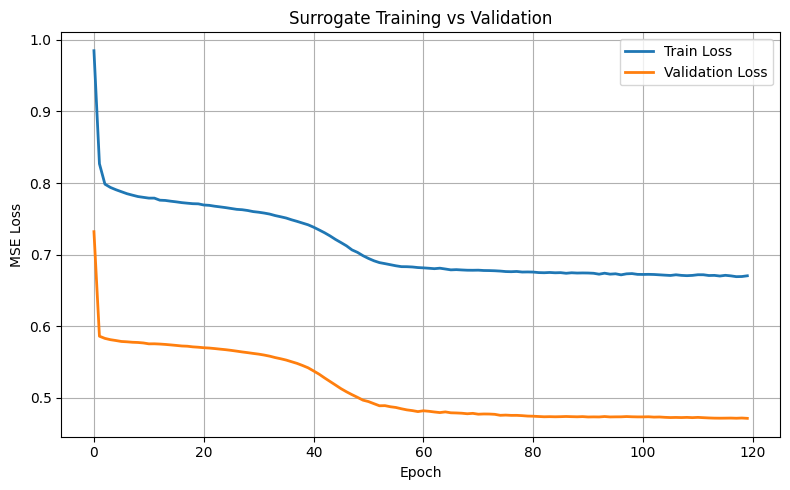

In [10]:
if TRAIN_SURROGATE:

    print("\n==============================")
    print(" TRAINING SURROGATE MODEL g(D, sigma) → <C(r)>")
    print("==============================\n")

    # -------------------------------------------------
    # Helper: load ALL images for one (D, sigma) group
    # (NO augmentations, ONLY ToTensor)
    # -------------------------------------------------
    def load_group_imgs(img_paths, device):
        imgs = []
        for p in img_paths:
            img = Image.open(p).convert("L")
            img = val_tf(img)              # ONLY ToTensor
            img = img.repeat(3, 1, 1)      # [1,H,W] -> [3,H,W]
            imgs.append(img)
        return torch.stack(imgs).to(device)  # [N,3,H,W]

    # -------------------------------------------------
    # Determine phi_dim dynamically
    # -------------------------------------------------
    sample_item = train_surr[0]
    sample_imgs = load_group_imgs(sample_item["img_paths"], device)
    with torch.no_grad():
        sample_phi = compute_image_observables(sample_imgs)  # [N, phi_dim]
    phi_dim = sample_phi.shape[1]
    print("Phi dimension:", phi_dim)

    # -------------------------------------------------
    # Build surrogate with correct output size
    # -------------------------------------------------
    surrogate = SurrogatePhysics(phi_dim=phi_dim).to(device)
    optimizer_surr = torch.optim.Adam(surrogate.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    # -------------------------------------------------
    # Compute Φ statistics on TRAIN surrogate set
    # (using <Φ> per (D, sigma) group)
    # -------------------------------------------------
    Phi_list = []
    with torch.no_grad():
        for item in train_surr:
            imgs = load_group_imgs(item["img_paths"], device)
            Phi = compute_image_observables(imgs)     # [N, phi_dim]
            Phi_bar = Phi.mean(dim=0)                 # [phi_dim]
            Phi_list.append(Phi_bar.cpu())

    Phi_all = torch.stack(Phi_list, dim=0)            # [n_groups, phi_dim]

    Phi_mean = Phi_all.mean(dim=0)                    # [phi_dim]
    Phi_std  = Phi_all.std(dim=0)                     # [phi_dim]
    Phi_std[Phi_std == 0] = 1.0

    Phi_mean = Phi_mean.to(device)
    Phi_std  = Phi_std.to(device)

    print("Phi mean (train) first 5:", Phi_mean[:5].detach().cpu())
    print("Phi std  (train) first 5:", Phi_std[:5].detach().cpu())

    # -------------------------------------------------
    # Training loop
    # -------------------------------------------------
    epochs = 120
    train_losses = []
    val_losses = []

    for epoch in range(1, epochs + 1):

        # -----------------------------
        # TRAIN
        # -----------------------------
        surrogate.train()
        running_train = 0.0

        for item in train_surr:
            params = item["params"].to(device)         # [2] in PHYSICAL units
            imgs = load_group_imgs(item["img_paths"], device)

            with torch.no_grad():
                Phi = compute_image_observables(imgs)  # [N, phi_dim]
                Phi_bar = Phi.mean(dim=0)              # [phi_dim]
                Phi_bar = (Phi_bar - Phi_mean) / Phi_std

            Phi_pred = surrogate(params.unsqueeze(0)).squeeze(0)  # [phi_dim]

            loss = criterion(Phi_pred, Phi_bar)

            optimizer_surr.zero_grad()
            loss.backward()
            optimizer_surr.step()

            running_train += loss.item()

        train_loss = running_train / len(train_surr)
        train_losses.append(train_loss)

        # -----------------------------
        # VALIDATION
        # -----------------------------
        surrogate.eval()
        running_val = 0.0

        with torch.no_grad():
            for item in val_surr:
                params = item["params"].to(device)     # [2]
                imgs = load_group_imgs(item["img_paths"], device)

                Phi = compute_image_observables(imgs)  # [N, phi_dim]
                Phi_bar = Phi.mean(dim=0)
                Phi_bar = (Phi_bar - Phi_mean) / Phi_std

                Phi_pred = surrogate(params.unsqueeze(0)).squeeze(0)

                running_val += criterion(Phi_pred, Phi_bar).item()

        val_loss = running_val / len(val_surr)
        val_losses.append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d}/{epochs} | "
                f"Train: {train_loss:.6f} | "
                f"Val: {val_loss:.6f}"
            )

    # -------------------------------------------------
    # Freeze and save
    # -------------------------------------------------
    for p in surrogate.parameters():
        p.requires_grad = False
    surrogate.eval()

    torch.save({
        "state_dict": surrogate.state_dict(),
        "Phi_mean": Phi_mean.detach().cpu(),
        "Phi_std": Phi_std.detach().cpu(),
        "phi_dim": phi_dim
    }, "surrogate_corr.pt")

    print("\nSurrogate saved to 'surrogate_corr.pt'")

    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss", linewidth=2)
    plt.plot(val_losses, label="Validation Loss", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Surrogate Training vs Validation")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("surrogate_train_val_curve_corr.png", dpi=300)
    plt.show()


In [11]:
# -----------------------------
# Model Initialization
# PhysicsNormal ONLY
# -----------------------------

print("\n==============================")
print(" Initializing PhysicsNormal model (C(r) physics)")
print("==============================\n")

# -------------------------------------------------
# CNN: image → (D, sigma)
# -------------------------------------------------
model = PhysicsNormalCNN().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-3
)

# -------------------------------------------------
# Load trained surrogate physics model
# -------------------------------------------------
SURR_PATH = "surrogate_corr.pt"
assert os.path.exists(SURR_PATH), (
    f"{SURR_PATH} not found. Train surrogate before training PhysicsNormal."
)

ckpt = torch.load(SURR_PATH, map_location=device)

phi_dim = ckpt["phi_dim"]
Phi_mean = ckpt["Phi_mean"].to(device)
Phi_std  = ckpt["Phi_std"].to(device)

surrogate = SurrogatePhysics(phi_dim=phi_dim).to(device)
surrogate.load_state_dict(ckpt["state_dict"])
surrogate.eval()

# Freeze surrogate
for p in surrogate.parameters():
    p.requires_grad = False

print(f"Loaded surrogate with phi_dim = {phi_dim}")

# -------------------------------------------------
# Loss function (data + physics)
# -------------------------------------------------
criterion = nn.MSELoss()

# -------------------------------------------------
# LR scheduler (monitor TOTAL loss)
# -------------------------------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

best_val_loss = float("inf")
BEST_PATH = "best_physicsnormal_model_corr.pt"

print(f"PhysicsNormal initialized with LR={LR}")
print(f"Best model will be saved to: {BEST_PATH}\n")


 Initializing PhysicsNormal model (C(r) physics)

Loaded surrogate with phi_dim = 65
PhysicsNormal initialized with LR=5e-05
Best model will be saved to: best_physicsnormal_model_corr.pt



Epoch 001 | Train: 7.0442e-01 | Data: 6.6685e-01 | Phys: 7.5122e-01 | Val: 5.2568e-01 | ValData: 5.0302e-01 | λ_phys=0.05 | LR=5.0e-05
 -> Saved new best model.
Epoch 002 | Train: 5.8887e-01 | Data: 5.1988e-01 | Phys: 6.8997e-01 | Val: 8.2402e-01 | ValData: 7.7228e-01 | λ_phys=0.10 | LR=5.0e-05
Epoch 003 | Train: 5.4568e-01 | Data: 4.4371e-01 | Phys: 6.7979e-01 | Val: 7.4043e-01 | ValData: 6.6369e-01 | λ_phys=0.15 | LR=5.0e-05
Epoch 004 | Train: 5.0810e-01 | Data: 3.7527e-01 | Phys: 6.6417e-01 | Val: 4.5263e-01 | ValData: 3.6269e-01 | λ_phys=0.20 | LR=5.0e-05
 -> Saved new best model.
Epoch 005 | Train: 5.0279e-01 | Data: 3.3453e-01 | Phys: 6.7304e-01 | Val: 7.3339e-01 | ValData: 6.2410e-01 | λ_phys=0.25 | LR=5.0e-05
Epoch 006 | Train: 5.1689e-01 | Data: 3.1898e-01 | Phys: 6.5971e-01 | Val: 3.8301e-01 | ValData: 2.6016e-01 | λ_phys=0.30 | LR=5.0e-05
 -> Saved new best model.
Epoch 007 | Train: 5.3975e-01 | Data: 3.1100e-01 | Phys: 6.5357e-01 | Val: 7.6231e-01 | ValData: 6.2578e-01 | λ_

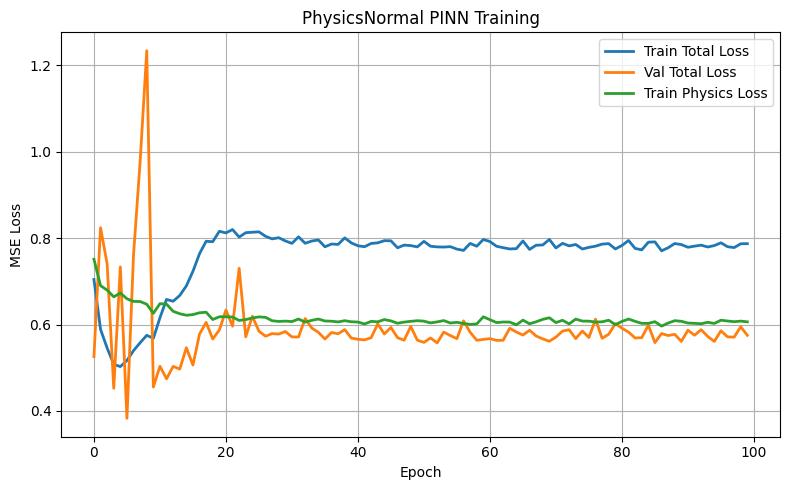

In [12]:
# ============================================================
# Training loop — PhysicsNormal PINN (FINAL)
# ============================================================

train_losses = []
val_losses = []
physics_losses = []

train_data_losses = []
val_data_losses = []

lambda_list = []

lambda_data = 1.0
t_mean_t = torch.tensor(t_mean, device=device, dtype=torch.float32)
t_std_t  = torch.tensor(t_std,  device=device, dtype=torch.float32)

for epoch in range(1, EPOCHS + 1):

    # -------------------------------------------------
    # Physics curriculum (always active)
    # -------------------------------------------------
    lambda_phys = min(1.0, epoch / 20)
    lambda_list.append(lambda_phys)

    # ==========================
    #        TRAIN
    # ==========================
    model.train()
    running_train = 0.0
    running_phys = 0.0
    running_train_data = 0.0

    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        # --------------------------
        # Forward CNN
        # --------------------------
        outputs = model(imgs)

        # --------------------------
        # Data loss (supervised)
        # --------------------------
        loss_data = criterion(outputs, targets)

        # --------------------------
        # Physics loss
        # --------------------------
        with torch.no_grad():
            Phi_img = compute_image_observables(imgs)
            Phi_img = (Phi_img - Phi_mean) / Phi_std

        # Unnormalize CNN outputs → physical units
        params_phys = outputs * t_std_t + t_mean_t

        Phi_pred = surrogate(params_phys)
        loss_phys = F.mse_loss(Phi_pred, Phi_img)

        # --------------------------
        # Total loss
        # --------------------------
        loss = lambda_data * loss_data + lambda_phys * loss_phys

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_train += loss.item() * imgs.size(0)
        running_train_data += loss_data.item() * imgs.size(0)
        running_phys += loss_phys.item() * imgs.size(0)

    epoch_train_loss = running_train / len(train_loader.dataset)
    epoch_train_data = running_train_data / len(train_loader.dataset)
    epoch_train_phys = running_phys / len(train_loader.dataset)

    train_losses.append(epoch_train_loss)
    train_data_losses.append(epoch_train_data)
    physics_losses.append(epoch_train_phys)

    # ==========================
    #      VALIDATION
    # ==========================
    model.eval()
    running_val = 0.0
    running_val_data = 0.0

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)

            outputs = model(imgs)
            loss_data = criterion(outputs, targets)

            Phi_img = compute_image_observables(imgs)
            Phi_img = (Phi_img - Phi_mean) / Phi_std

            params_phys = outputs * t_std_t + t_mean_t
            Phi_pred = surrogate(params_phys)
            loss_phys = F.mse_loss(Phi_pred, Phi_img)

            loss = lambda_data * loss_data + lambda_phys * loss_phys

            running_val += loss.item() * imgs.size(0)
            running_val_data += loss_data.item() * imgs.size(0)

    epoch_val_loss = running_val / len(val_loader.dataset)
    epoch_val_data = running_val_data / len(val_loader.dataset)

    val_losses.append(epoch_val_loss)
    val_data_losses.append(epoch_val_data)

    # ==========================
    #   Scheduler & logging
    # ==========================
    scheduler.step(epoch_val_loss)
    lr_now = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:03d} | "
        f"Train: {epoch_train_loss:.4e} | "
        f"Data: {epoch_train_data:.4e} | "
        f"Phys: {epoch_train_phys:.4e} | "
        f"Val: {epoch_val_loss:.4e} | "
        f"ValData: {epoch_val_data:.4e} | "
        f"λ_phys={lambda_phys:.2f} | "
        f"LR={lr_now:.1e}"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save({
            "model_state_dict": model.state_dict(),
            "target_mean": t_mean,
            "target_std": t_std
        }, BEST_PATH)
        print(" -> Saved new best model.")

# ============================================================
# Plot losses
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Total Loss", linewidth=2)
plt.plot(val_losses, label="Val Total Loss", linewidth=2)
plt.plot(physics_losses, label="Train Physics Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("PhysicsNormal PINN Training")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


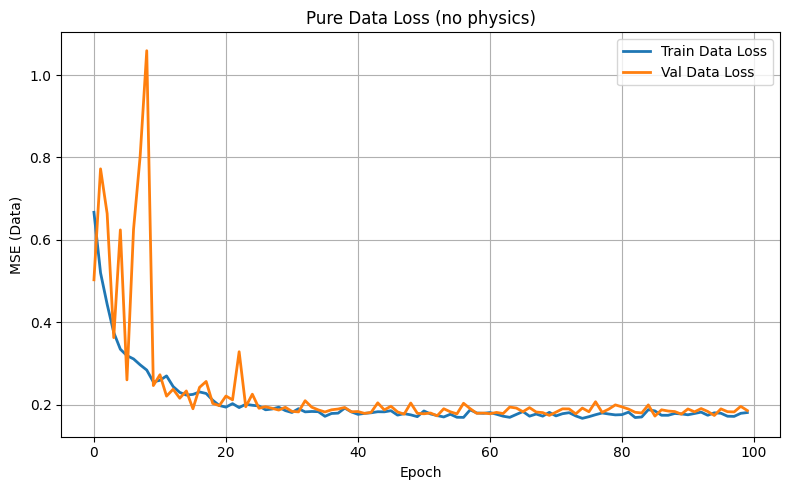

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(train_data_losses, label="Train Data Loss", linewidth=2)
plt.plot(val_data_losses, label="Val Data Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE (Data)")
plt.title("Pure Data Loss (no physics)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("data_loss_curve_4.png", dpi=300)
plt.show()


In [14]:
def get_ground_truth(img_path, csv_path):
    """
    Extracts run_id from filename mz_binary_<run_id>.png
    and looks up D and sigma in CSV.
    """
    filename = Path(img_path).stem  # mz_binary_123
    try:
        run_id = int(filename.split("_")[-1])
    except ValueError:
        raise ValueError(f"Cannot parse run_id from filename: {filename}")

    df = pd.read_csv(csv_path)
    row = df[df[IMG_INDEX_COL] == run_id]

    if row.empty:
        raise KeyError(f"run_id {run_id} not found in CSV")

    return float(row.iloc[0][COL_D]), float(row.iloc[0][COL_SIGMA])


def load_model(path):
    """
    Load trained PhysicsNormalCNN model for inference.
    """
    checkpoint = torch.load(path, map_location=device, weights_only=False)

    model = PhysicsNormalCNN().to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    target_mean = checkpoint["target_mean"]
    target_std  = checkpoint["target_std"]

    return model, target_mean, target_std


# -------------------------------------------------
# Transform for prediction (NO augmentations)
# -------------------------------------------------
predict_tf = T.Compose([
    T.ToTensor(),
])


In [17]:
# -----------------------------
# 8) Execution: Predict & Compare
# -----------------------------

# -------------------------------------------------
# Prediction function (clean)
# -------------------------------------------------
def predict_image(img_path, model, target_mean, target_std):
    img = Image.open(img_path).convert("L")
    img = predict_tf(img)

    if img.shape[0] == 1:
        img = img.repeat(3, 1, 1)

    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        out_norm = model(img).cpu().numpy()[0]

    # Unnormalize (physical units)
    out = out_norm * target_std + target_mean
    return float(out[0]), float(out[1])


# -------------------------------------------------
# Load trained PhysicsNormal model
# -------------------------------------------------
model, tm, ts = load_model(BEST_PATH)

# Example image
test_img_path = "../dataset_combined/images/mz_binary_645.png"

# Predict
pred_D, pred_sigma = predict_image(test_img_path, model, tm, ts)

# Ground truth
real_D, real_sigma = get_ground_truth(test_img_path, CSV_PATH)

# -------------------------------------------------
# Report
# -------------------------------------------------
print("-" * 60)
print("Model: PhysicsNormalCNN")
print(f"Image: {Path(test_img_path).name}")
print("-" * 60)
print(f"{'Parameter':<10} | {'Real':<12} | {'Predicted':<12} | {'Abs Error':<12}")
print("-" * 60)
print(f"{'D':<10} | {real_D:.6f} | {pred_D:.6f} | {abs(pred_D-real_D):.6f}")
print(f"{'Sigma':<10} | {real_sigma:.6f} | {pred_sigma:.6f} | {abs(pred_sigma-real_sigma):.6f}")
print("-" * 60)


------------------------------------------------------------
Model: PhysicsNormalCNN
Image: mz_binary_645.png
------------------------------------------------------------
Parameter  | Real         | Predicted    | Abs Error   
------------------------------------------------------------
D          | 0.001214 | 0.001442 | 0.000228
Sigma      | 0.085707 | 0.089047 | 0.003340
------------------------------------------------------------


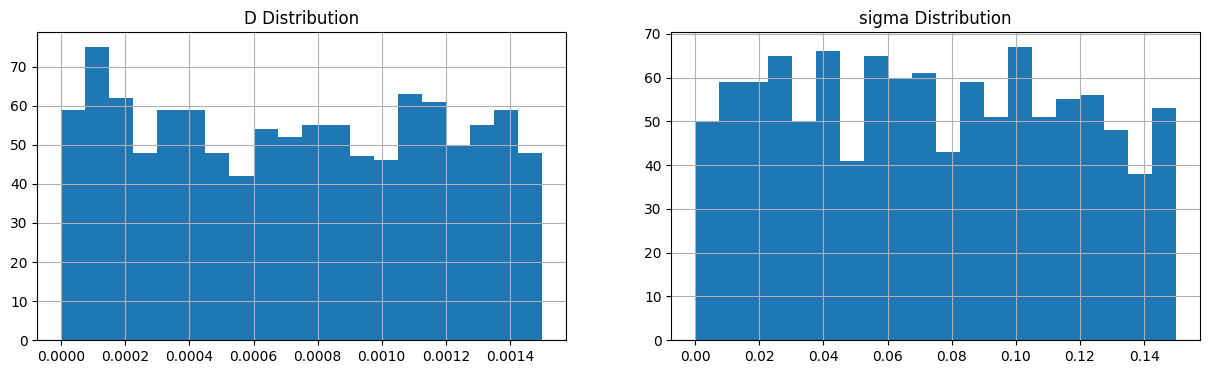

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../dataset_combined/training_index.csv")

plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
df["Dind"].hist(bins=20)
plt.title("D Distribution")

plt.subplot(1,2,2)
df["sigma"].hist(bins=20)
plt.title("sigma Distribution")

plt.show()


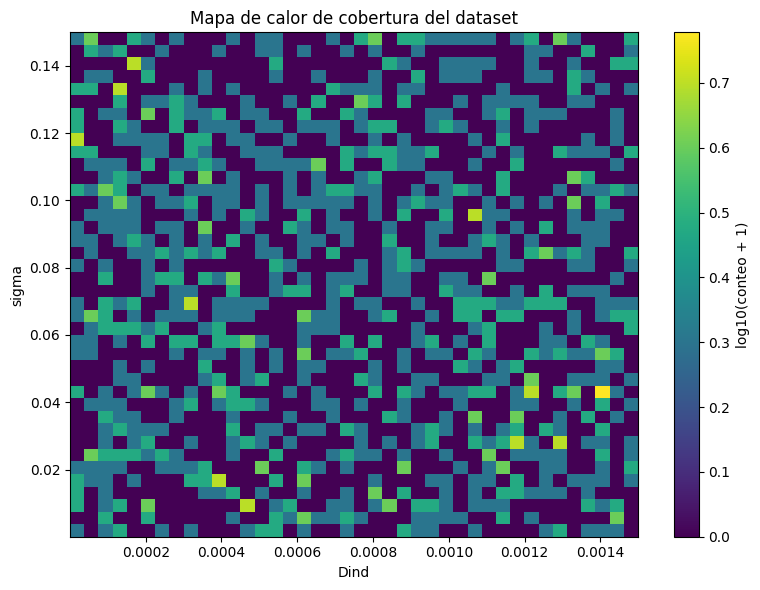

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_D_sigma_heatmap(
    csv_path,
    D_col="Dind",
    sigma_col="sigma",
    bins_D=30,
    bins_sigma=30,
    log_scale=True
):
    """
    Genera un mapa de calor del conteo de muestras en el plano (D, sigma)

    Parameters
    ----------
    csv_path : str
        Ruta al archivo CSV
    D_col : str
        Nombre de la columna de D
    sigma_col : str
        Nombre de la columna de sigma
    bins_D : int
        Número de bins para D
    bins_sigma : int
        Número de bins para sigma
    log_scale : bool
        Si True, usa escala logarítmica para el color
    """

    # ---------------------------
    # Leer datos
    # ---------------------------
    df = pd.read_csv(csv_path)

    if D_col not in df.columns or sigma_col not in df.columns:
        raise ValueError("Las columnas especificadas no existen en el CSV")

    D = df[D_col].values
    sigma = df[sigma_col].values


    # ---------------------------
    # Binning y conteo
    # ---------------------------
    H, D_edges, sigma_edges = np.histogram2d(
        D,
        sigma,
        bins=[bins_D, bins_sigma]
    )

    if log_scale:
        H = np.log10(H + 1.0)

    # ---------------------------
    # Plot
    # ---------------------------
    plt.figure(figsize=(8, 6))

    extent = [
        D_edges[0], D_edges[-1],
        sigma_edges[0], sigma_edges[-1]
    ]

    im = plt.imshow(
        H.T,
        origin="lower",
        aspect="auto",
        extent=extent
    )

    cbar = plt.colorbar(im)
    cbar.set_label("log10(conteo + 1)" if log_scale else "conteo")

    plt.xlabel(D_col)
    plt.ylabel(sigma_col)
    plt.title("Mapa de calor de cobertura del dataset")

    plt.tight_layout()
    plt.savefig("D_sigma_heatmap_combined_1000.png", dpi=300)
    plt.show()


plot_D_sigma_heatmap(
    csv_path="../dataset_combined/training_index.csv",
    D_col="Dind",
    sigma_col="sigma",
    bins_D=40,
    bins_sigma=40,
    log_scale=True
)


In [20]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm


def collect_prediction_errors(
    image_dir,
    csv_path,
    model,
    target_mean,
    target_std,
):
    """
    Run inference on all images listed in csv_path and
    collect prediction errors for D and sigma.
    """
    records = []

    df = pd.read_csv(csv_path)

    for row in tqdm(df.itertuples(index=False), total=len(df), desc="Predicting"):
        run_id = int(getattr(row, IMG_INDEX_COL))
        img_path = Path(image_dir) / f"mz_binary_{run_id}.png"

        if not img_path.exists():
            raise FileNotFoundError(
                f"Missing image for run_id={run_id}: {img_path}"
            )

        # Ground truth
        real_D = float(getattr(row, COL_D))
        real_sigma = float(getattr(row, COL_SIGMA))

        # Prediction
        pred_D, pred_sigma = predict_image(
            img_path, model, target_mean, target_std
        )

        records.append({
            "run_id": run_id,
            "Dind": real_D,
            "sigma": real_sigma,
            "pred_D": pred_D,
            "pred_sigma": pred_sigma,
            "err_D": abs(pred_D - real_D),
            "err_sigma": abs(pred_sigma - real_sigma),
        })

    return pd.DataFrame.from_records(records)


# -------------------------------------------------
# Run evaluation
# -------------------------------------------------
df_err = collect_prediction_errors(
    image_dir=IMG_DIR,
    csv_path=CSV_PATH,
    model=model,
    target_mean=tm,
    target_std=ts,
)


Predicting: 100%|██████████| 1097/1097 [00:06<00:00, 166.54it/s]


In [21]:
def plot_error_heatmap(
    df_err,
    csv_limits_path,
    D_col="Dind",
    sigma_col="sigma",
    err_col="err_D",
    bins_D=40,
    bins_sigma=40,
    statistic="mean",          # "mean" or "median"
    title="",
    cmap="inferno",
    vmin=None,
    vmax=None,
    save_path=None
):
    """
    Heatmap of prediction error in the (D, sigma) plane,
    using the physical domain defined by the training CSV.

    statistic:
        "mean"   → average error per bin
        "median" → median error per bin (robust)
    """

    # --------------------------------------------------
    # 1. Physical domain (authoritative)
    # --------------------------------------------------
    df_limits = pd.read_csv(csv_limits_path)
    df_limits = df_limits.dropna(subset=[D_col, sigma_col])

    D_min, D_max = df_limits[D_col].min(), df_limits[D_col].max()
    s_min, s_max = df_limits[sigma_col].min(), df_limits[sigma_col].max()

    print(f"[Domain] D:     {D_min:.6g} → {D_max:.6g}")
    print(f"[Domain] sigma: {s_min:.6g} → {s_max:.6g}")

    if D_min == D_max or s_min == s_max:
        raise ValueError("Degenerate range in D or sigma")

    # --------------------------------------------------
    # 2. Physical bins
    # --------------------------------------------------
    D_edges = np.linspace(D_min, D_max, bins_D + 1)
    s_edges = np.linspace(s_min, s_max, bins_sigma + 1)

    # --------------------------------------------------
    # 3. Clean error data
    # --------------------------------------------------
    df = df_err.dropna(subset=[D_col, sigma_col, err_col])

    D = df[D_col].values
    s = df[sigma_col].values
    e = df[err_col].values

    # --------------------------------------------------
    # 4. Bin assignment
    # --------------------------------------------------
    iD = np.searchsorted(D_edges, D, side="right") - 1
    iS = np.searchsorted(s_edges, s, side="right") - 1

    valid = (
        (iD >= 0) & (iD < bins_D) &
        (iS >= 0) & (iS < bins_sigma)
    )

    iD, iS, e = iD[valid], iS[valid], e[valid]

    # --------------------------------------------------
    # 5. Accumulate statistics
    # --------------------------------------------------
    if statistic == "mean":
        sum_err = np.zeros((bins_D, bins_sigma), dtype=float)
        counts  = np.zeros((bins_D, bins_sigma), dtype=int)

        np.add.at(sum_err, (iD, iS), e)
        np.add.at(counts,  (iD, iS), 1)

        with np.errstate(divide="ignore", invalid="ignore"):
            heatmap = sum_err / counts
            heatmap[counts == 0] = np.nan

    elif statistic == "median":
        bins = [[[] for _ in range(bins_sigma)] for _ in range(bins_D)]
        for d, s_, err in zip(iD, iS, e):
            bins[d][s_].append(err)

        heatmap = np.full((bins_D, bins_sigma), np.nan)
        counts  = np.zeros((bins_D, bins_sigma), dtype=int)

        for i in range(bins_D):
            for j in range(bins_sigma):
                if bins[i][j]:
                    heatmap[i, j] = np.median(bins[i][j])
                    counts[i, j] = len(bins[i][j])

    else:
        raise ValueError("statistic must be 'mean' or 'median'")

    # --------------------------------------------------
    # 6. Plot (D on x, sigma on y)
    # --------------------------------------------------
    plt.figure(figsize=(8, 6))
    im = plt.imshow(
        heatmap.T,
        origin="lower",
        aspect="auto",
        extent=[D_min, D_max, s_min, s_max],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    plt.colorbar(im, label=err_col)
    plt.xlabel(D_col)
    plt.ylabel(sigma_col)
    plt.title(title)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()

    return heatmap, counts


[Domain] D:     1.06272e-07 → 0.00149959
[Domain] sigma: 6.77804e-05 → 0.149908


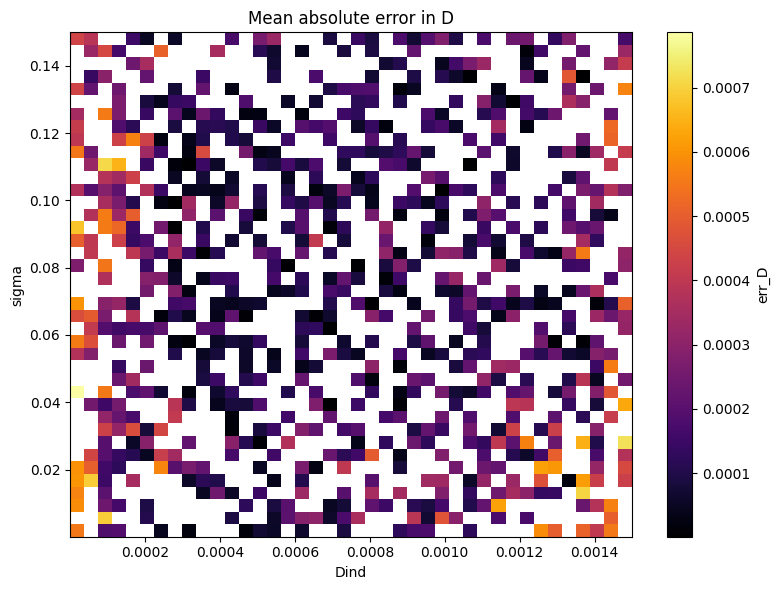

(array([[0.00055569,        nan, 0.00058847, ...,        nan,        nan,
         0.00043741],
        [       nan,        nan,        nan, ...,        nan, 0.00032689,
         0.00038798],
        [0.00018412, 0.00069197, 0.00024084, ...,        nan, 0.00045084,
                nan],
        ...,
        [0.00040331,        nan, 0.00037966, ...,        nan,        nan,
                nan],
        [0.00055321, 0.00050564, 0.00056754, ..., 0.00031313,        nan,
                nan],
        [       nan,        nan,        nan, ..., 0.00041264, 0.00032867,
         0.00016943]], shape=(40, 40)),
 array([[1, 0, 2, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 2, 3],
        [1, 2, 1, ..., 0, 1, 0],
        ...,
        [1, 0, 1, ..., 0, 0, 0],
        [1, 3, 2, ..., 2, 0, 0],
        [0, 0, 0, ..., 2, 1, 2]], shape=(40, 40)))

In [22]:
plot_error_heatmap(
    df_err,
    CSV_PATH,
    err_col="err_D",
    title="Mean absolute error in D",
    statistic="mean"
)


[Domain] D:     1.06272e-07 → 0.00149959
[Domain] sigma: 6.77804e-05 → 0.149908


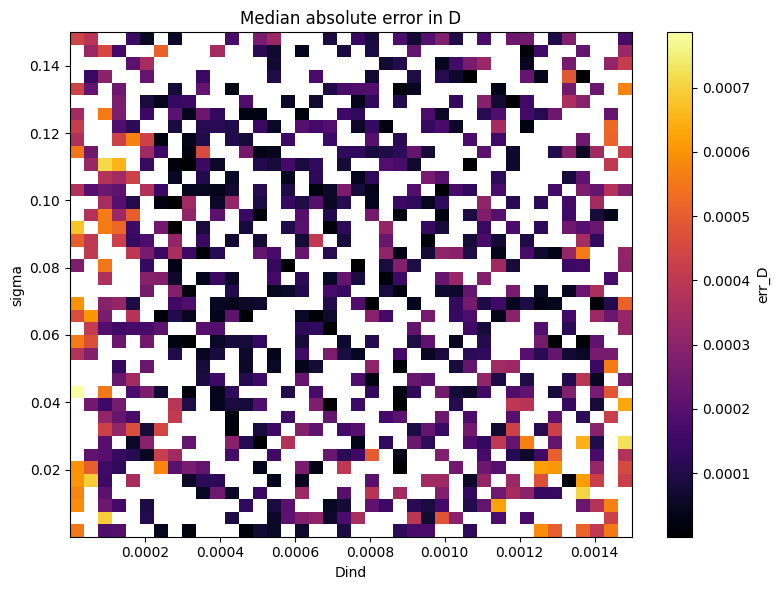

(array([[0.00055569,        nan, 0.00058847, ...,        nan,        nan,
         0.00043741],
        [       nan,        nan,        nan, ...,        nan, 0.00032689,
         0.00038972],
        [0.00018412, 0.00069197, 0.00024084, ...,        nan, 0.00045084,
                nan],
        ...,
        [0.00040331,        nan, 0.00037966, ...,        nan,        nan,
                nan],
        [0.00055321, 0.0004335 , 0.00056754, ..., 0.00031313,        nan,
                nan],
        [       nan,        nan,        nan, ..., 0.00041264, 0.00032867,
         0.00016943]], shape=(40, 40)),
 array([[1, 0, 2, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 2, 3],
        [1, 2, 1, ..., 0, 1, 0],
        ...,
        [1, 0, 1, ..., 0, 0, 0],
        [1, 3, 2, ..., 2, 0, 0],
        [0, 0, 0, ..., 2, 1, 2]], shape=(40, 40)))

In [23]:
plot_error_heatmap(
    df_err,
    CSV_PATH,
    err_col="err_D",
    title="Median absolute error in D",
    statistic="median"
)


[Domain] D:     1.06272e-07 → 0.00149959
[Domain] sigma: 6.77804e-05 → 0.149908


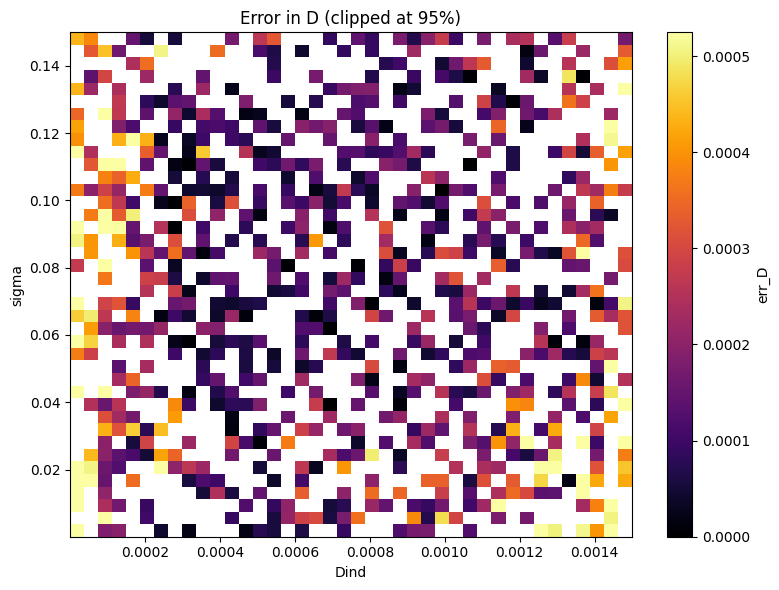

(array([[0.00055569,        nan, 0.00058847, ...,        nan,        nan,
         0.00043741],
        [       nan,        nan,        nan, ...,        nan, 0.00032689,
         0.00038798],
        [0.00018412, 0.00069197, 0.00024084, ...,        nan, 0.00045084,
                nan],
        ...,
        [0.00040331,        nan, 0.00037966, ...,        nan,        nan,
                nan],
        [0.00055321, 0.00050564, 0.00056754, ..., 0.00031313,        nan,
                nan],
        [       nan,        nan,        nan, ..., 0.00041264, 0.00032867,
         0.00016943]], shape=(40, 40)),
 array([[1, 0, 2, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 2, 3],
        [1, 2, 1, ..., 0, 1, 0],
        ...,
        [1, 0, 1, ..., 0, 0, 0],
        [1, 3, 2, ..., 2, 0, 0],
        [0, 0, 0, ..., 2, 1, 2]], shape=(40, 40)))

In [25]:
vmax = np.nanpercentile(df_err["err_D"], 95)

plot_error_heatmap(
    df_err,
    CSV_PATH,
    err_col="err_D",
    vmin=0,
    vmax=vmax,
    title="Error in D (clipped at 95%)"
)


[Domain] D:     1.06272e-07 → 0.00149959
[Domain] sigma: 6.77804e-05 → 0.149908


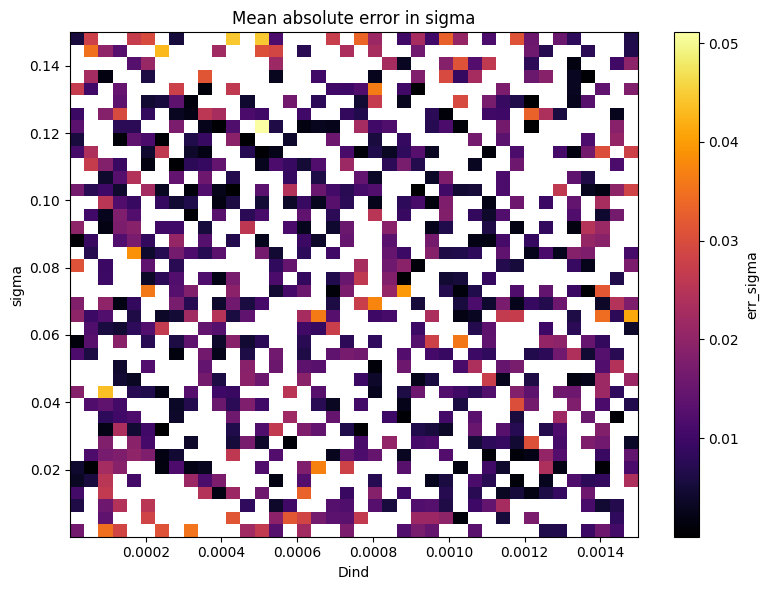

(array([[0.01634129,        nan, 0.0063791 , ...,        nan,        nan,
         0.00553197],
        [       nan,        nan,        nan, ...,        nan, 0.03504531,
         0.02784662],
        [0.03489603, 0.01393595, 0.01565089, ...,        nan, 0.0199723 ,
                nan],
        ...,
        [0.01564244,        nan, 0.00458169, ...,        nan,        nan,
                nan],
        [0.01049144, 0.00829145, 0.00683222, ..., 0.00998922,        nan,
                nan],
        [       nan,        nan,        nan, ..., 0.01974093, 0.00666594,
         0.0065896 ]], shape=(40, 40)),
 array([[1, 0, 2, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 2, 3],
        [1, 2, 1, ..., 0, 1, 0],
        ...,
        [1, 0, 1, ..., 0, 0, 0],
        [1, 3, 2, ..., 2, 0, 0],
        [0, 0, 0, ..., 2, 1, 2]], shape=(40, 40)))

In [26]:
plot_error_heatmap(
    df_err,
    CSV_PATH,
    err_col="err_sigma",
    title="Mean absolute error in sigma",
    statistic="mean"
)


In [77]:
import numpy as np

def bin_average_phi(
    df,
    D_edges,
    s_edges,
    phi_cols=("phi_0", "phi_1", "phi_2"),
    D_col="Dind",
    sigma_col="sigma",
):
    bins_D = len(D_edges) - 1
    bins_s = len(s_edges) - 1
    n_phi = len(phi_cols)

    phi_mean = np.full((bins_D, bins_s, n_phi), np.nan)
    counts   = np.zeros((bins_D, bins_s), dtype=int)

    D = df[D_col].values
    s = df[sigma_col].values
    Phi = df[list(phi_cols)].values

    iD = np.searchsorted(D_edges, D, side="right") - 1
    iS = np.searchsorted(s_edges, s, side="right") - 1

    valid = (
        (iD >= 0) & (iD < bins_D) &
        (iS >= 0) & (iS < bins_s)
    )

    iD, iS, Phi = iD[valid], iS[valid], Phi[valid]

    sum_phi = np.zeros((bins_D, bins_s, n_phi))

    for k in range(n_phi):
        np.add.at(sum_phi[..., k], (iD, iS), Phi[:, k])
    np.add.at(counts, (iD, iS), 1)

    mask = counts > 0
    for k in range(n_phi):
        phi_mean[..., k][mask] = sum_phi[..., k][mask] / counts[mask]

    return phi_mean, counts


In [79]:
def compute_phi_gradients(phi_mean, D_edges, s_edges):
    """
    Devuelve |∇Phi_k| y |∇Phi| total por bin.
    """
    bins_D, bins_s, n_phi = phi_mean.shape

    dD = np.mean(np.diff(D_edges))
    dS = np.mean(np.diff(s_edges))

    grad_phi = np.full_like(phi_mean, np.nan)

    for k in range(n_phi):
        phi_k = phi_mean[..., k]

        dPhi_dD = (phi_k[2:, 1:-1] - phi_k[:-2, 1:-1]) / (2 * dD)
        dPhi_dS = (phi_k[1:-1, 2:] - phi_k[1:-1, :-2]) / (2 * dS)

        grad_mag = np.sqrt(dPhi_dD**2 + dPhi_dS**2)

        grad_phi[1:-1, 1:-1, k] = grad_mag

    grad_total = np.sqrt(np.nansum(grad_phi**2, axis=2))

    return grad_phi, grad_total


In [80]:
import matplotlib.pyplot as plt

def plot_grad_heatmap(
    M,
    D_edges,
    s_edges,
    title="",
    cmap="inferno",
    log=False
):
    A = M.copy()
    if log:
        A = np.log10(A + 1e-12)

    plt.figure(figsize=(7,6))
    im = plt.imshow(
        A.T,
        origin="lower",
        aspect="auto",
        extent=[D_edges[0], D_edges[-1], s_edges[0], s_edges[-1]],
        cmap=cmap
    )
    plt.colorbar(im)
    plt.xlabel("Dind")
    plt.ylabel("sigma")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [84]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import torch
from PIL import Image

def collect_phi_per_image(
    image_dir,
    csv_path,
    device,
):
    records = []

    df = pd.read_csv(csv_path)

    # Normaliza nombres (muy importante para evitar bugs previos)
    df.columns = df.columns.str.strip().str.lower()

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Computing Phi"):
        run_id = int(row[IMG_INDEX_COL.lower()])
        img_path = Path(image_dir) / f"mz_binary_{run_id}.png"

        if not img_path.exists():
            raise FileNotFoundError(f"Imagen faltante: {img_path}")

        # Cargar imagen (idéntico preprocesamiento que en inferencia)
        img = Image.open(img_path).convert("L")
        img = predict_tf(img)

        if img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        img = img.unsqueeze(0).to(device)

        with torch.no_grad():
            phi = compute_image_observables(img).cpu().numpy()[0]

        records.append({
            "run_id": run_id,
            "Dind": row[COL_D.lower()],
            "sigma": row[COL_SIGMA.lower()],
            "phi_0": phi[0],
            "phi_1": phi[1],
            "phi_2": phi[2],
        })

    return pd.DataFrame(records)

df_phi = collect_phi_per_image(
    image_dir=IMG_DIR,
    csv_path=CSV_PATH,
    device=device,
)

print(df_phi.columns)
print(df_phi.head())



Computing Phi: 100%|██████████| 1097/1097 [00:03<00:00, 301.46it/s]

Index(['run_id', 'Dind', 'sigma', 'phi_0', 'phi_1', 'phi_2'], dtype='object')
   run_id      Dind     sigma     phi_0     phi_1     phi_2
0       1  0.000775  0.130362  0.011630  0.666790  0.971140
1       2  0.000195  0.109493  0.010049  0.663088  0.971715
2       3  0.000128  0.036694  0.006683  0.660892  0.983161
3       4  0.001058  0.096923  0.013257  0.668252  0.963261
4       5  0.000142  0.106838  0.009545  0.664531  0.977011


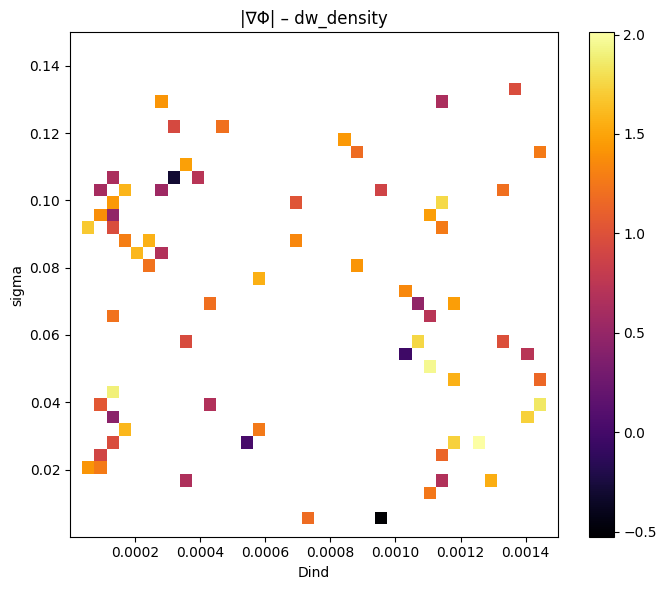

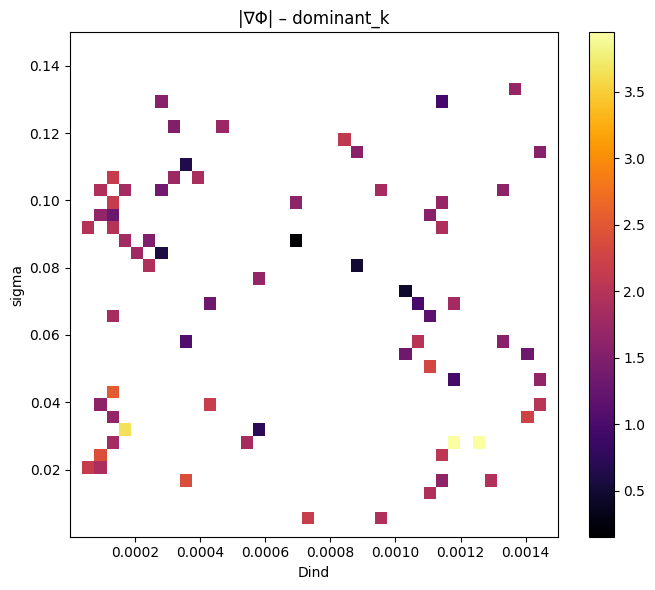

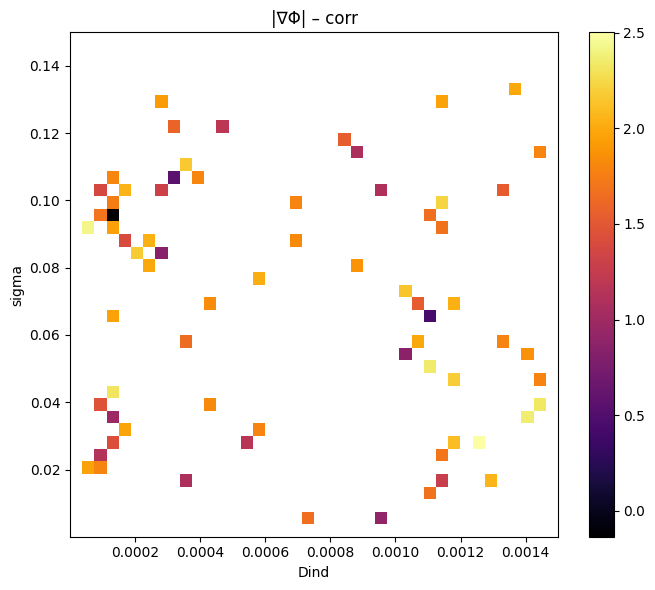

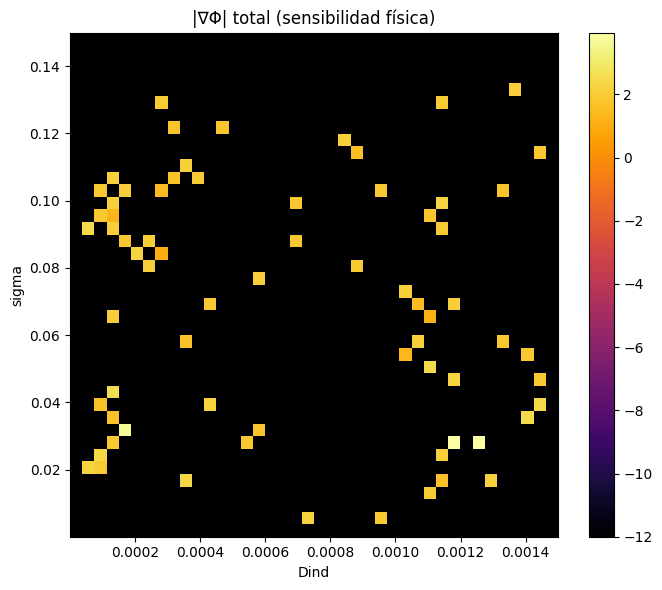

In [85]:
# Edges (los mismos que usas siempre)
df_master = pd.read_csv(CSV_PATH).dropna(subset=["Dind","sigma"])
D_edges = np.linspace(df_master["Dind"].min(), df_master["Dind"].max(), 41)
s_edges = np.linspace(df_master["sigma"].min(), df_master["sigma"].max(), 41)

# Bin-averaged Phi
phi_mean, counts = bin_average_phi(
    df_phi,   # DataFrame con D, sigma y phi_*
    D_edges,
    s_edges
)

# Gradientes
grad_phi, grad_total = compute_phi_gradients(phi_mean, D_edges, s_edges)

# Plots individuales
names = ["dw_density", "dominant_k", "corr"]

for k, name in enumerate(names):
    plot_grad_heatmap(
        grad_phi[..., k],
        D_edges,
        s_edges,
        title=f"|∇Φ| – {name}",
        log=True
    )

# Plot global
plot_grad_heatmap(
    grad_total,
    D_edges,
    s_edges,
    title="|∇Φ| total (sensibilidad física)",
    log=True
)


In [8]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

def extract_phi_and_params(dataset, batch_size=32):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    Phi_list = []      # aquí se acumula Φ
    D_list = []        # aquí se acumula D
    sigma_list = []    # aquí se acumula σ

    for imgs, targets in tqdm(loader, desc="Extracting Phi"):
        imgs = imgs.to(device)

        with torch.no_grad():
            Phi = compute_image_observables(imgs)  # [B,3]

        Phi_list.append(Phi.cpu().numpy())
        D_list.append(targets[:, 0].cpu().numpy())
        sigma_list.append(targets[:, 1].cpu().numpy())

    # AQUÍ se definen explícitamente
    Phi_all = np.vstack(Phi_list)          # shape [N,3]
    D_all = np.concatenate(D_list)         # shape [N]
    sigma_all = np.concatenate(sigma_list) # shape [N]

    return Phi_all, D_all, sigma_all


In [12]:
Phi_all, D_all, sigma_all = extract_phi_and_params(base_dataset)

Phi_mean = Phi_all.mean(axis=0)
Phi_std  = Phi_all.std(axis=0)
Phi_std[Phi_std == 0] = 1.0

Phi_norm = (Phi_all - Phi_mean) / Phi_std
print("Phi mean:", Phi_mean)
print("Phi std: ", Phi_std)

Extracting Phi: 100%|██████████| 35/35 [00:04<00:00,  7.62it/s]

Phi mean: [0.00951156 0.6571     0.9745779 ]
Phi std:  [0.00358005 0.06375979 0.01099514]


In [13]:
from sklearn.neighbors import NearestNeighbors

k = 10  # número de vecinos locales
nbrs = NearestNeighbors(n_neighbors=k+1)
nbrs.fit(Phi_norm)

distances, indices = nbrs.kneighbors(Phi_norm)


In [14]:
D_spread = []
sigma_spread = []

for i in range(len(Phi_norm)):
    neigh = indices[i, 1:]  # excluye el mismo punto

    D_local = D_all[neigh]
    sigma_local = sigma_all[neigh]

    D_spread.append(D_local.std())
    sigma_spread.append(sigma_local.std())

D_spread = np.array(D_spread)
sigma_spread = np.array(sigma_spread)


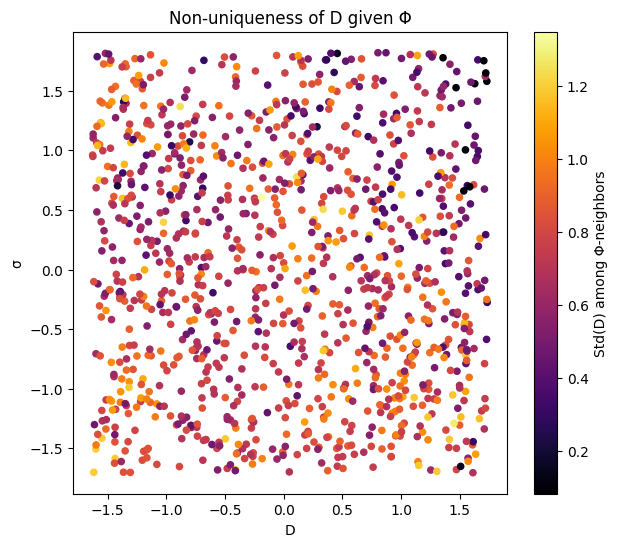

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
sc = plt.scatter(
    D_all, sigma_all,
    c=D_spread,
    cmap="inferno",
    s=20
)
plt.colorbar(sc, label="Std(D) among Φ-neighbors")
plt.xlabel("D")
plt.ylabel("σ")
plt.title("Non-uniqueness of D given Φ")
plt.show()


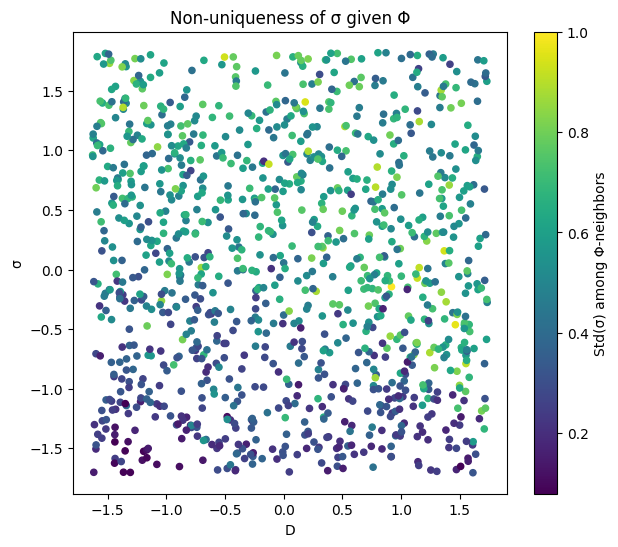

In [16]:
plt.figure(figsize=(7,6))
sc = plt.scatter(
    D_all, sigma_all,
    c=sigma_spread,
    cmap="viridis",
    s=20
)
plt.colorbar(sc, label="Std(σ) among Φ-neighbors")
plt.xlabel("D")
plt.ylabel("σ")
plt.title("Non-uniqueness of σ given Φ")
plt.show()
